In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def cpmg_segments(f_target, N_pi):
    """
    Kotler-style / lock-in CPMG sequence:
        pi/2 - tau - pi - tau - pi - ... - tau - pi/2

    Pi pulses are spaced by tau = 1/(2 f_target).
    N_pi is the number of pi pulses.
    """
    tau = 1 / (2 * f_target)
    pulse_times = tau * np.arange(1, N_pi + 1)
    T = (N_pi + 1) * tau

    edges = np.concatenate(([0.0], pulse_times, [T]))
    signs = (-1) ** np.arange(len(edges) - 1)

    return edges, signs, tau, T


def filter_response(freqs, edges, signs):
    """
    Computes Y(f) = integral y(t) exp(i 2 pi f t) dt exactly
    for a piecewise-constant toggling function y(t).
    """
    freqs = np.asarray(freqs)
    omega = 2 * np.pi * freqs

    t0 = edges[:-1]
    t1 = edges[1:]
    y = signs

    Y = np.zeros_like(freqs, dtype=complex)

    nonzero = np.abs(omega) > 1e-15

    w = omega[nonzero, None]
    Y[nonzero] = np.sum(
        y[None, :] * (np.exp(1j * w * t1[None, :]) - np.exp(1j * w * t0[None, :])) / (1j * w),
        axis=1
    )

    # DC limit
    Y[~nonzero] = np.sum(y * (t1 - t0))

    return Y

tau_pi-pi = 8.333 ms
total sequence time T = 91.7 ms


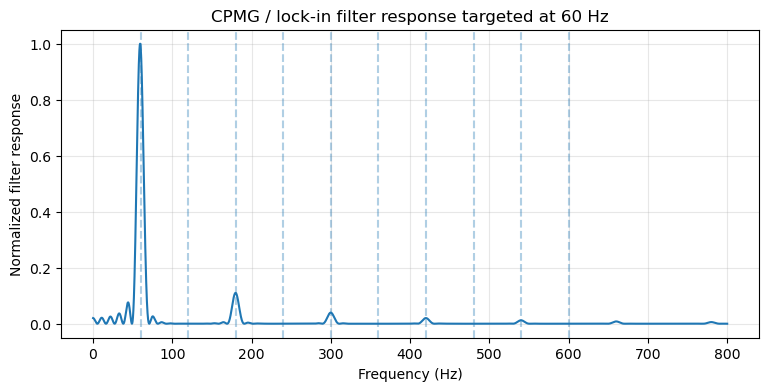

In [69]:
f_target = 60          # Hz
N_pi = 10              # number of pi pulses

edges, signs, tau, T = cpmg_segments(f_target, N_pi)

freqs = np.linspace(0.1, 800, 20000)
Y = filter_response(freqs, edges, signs)

# Normalize so the largest peak is 1
response = np.abs(Y)**2
response /= response.max()

print(f"tau_pi-pi = {tau*1e3:.3f} ms")
print(f"total sequence time T = {T*1e3:.1f} ms")

plt.figure(figsize=(9, 4))
# plt.semilogy(freqs, response)
plt.plot(freqs, response)
for n in range(1, 11):
    plt.axvline(60*n, linestyle="--", alpha=0.35)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized filter response")
plt.title(f"CPMG / lock-in filter response targeted at {f_target} Hz")
# plt.yscale("log")
# plt.ylim(1e-5, 1.2)
plt.grid(True, which="both", alpha=0.3)
plt.show()

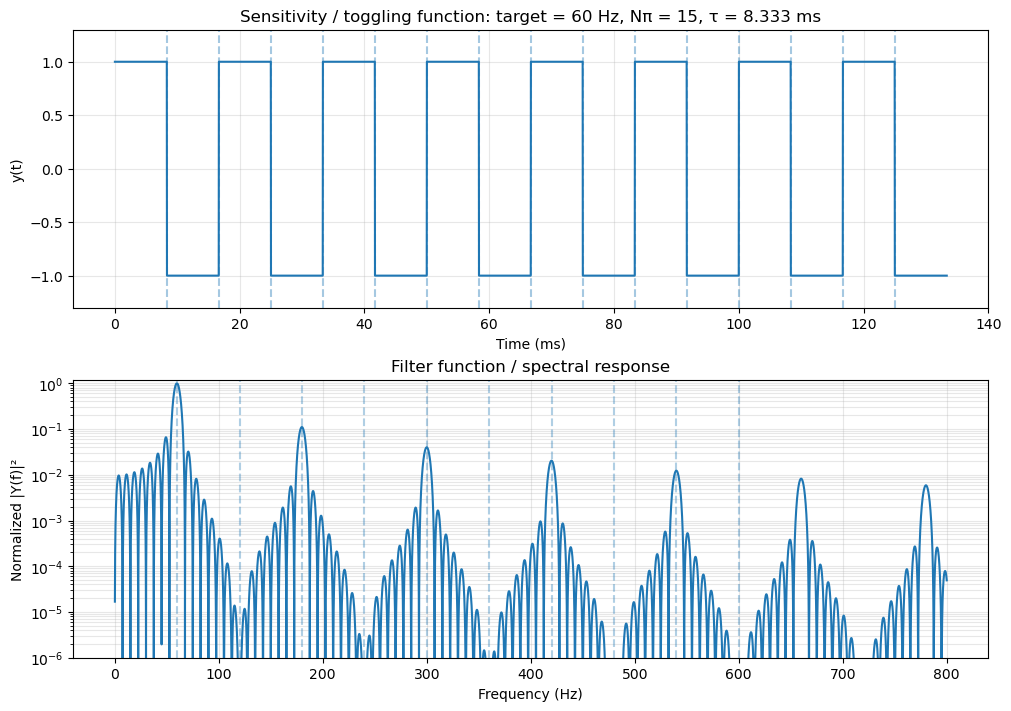

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def cpmg_toggling_function(f_target, N_pi):
    """
    CPMG / quantum lock-in sequence:
        pi/2 - tau - pi - tau - pi - ... - tau - pi/2

    The spacing between neighboring pi pulses is
        tau = 1 / (2 f_target)

    Returns:
        pulse_times : array of pi-pulse times
        edges       : segment boundaries
        signs       : y(t) value on each segment
        tau         : interpulse spacing
        T           : total sequence duration
    """
    tau = 1 / (2 * f_target)
    pulse_times = tau * np.arange(1, N_pi + 1)
    T = (N_pi + 1) * tau

    edges = np.concatenate(([0.0], pulse_times, [T]))
    signs = (-1) ** np.arange(len(edges) - 1)   # +1, -1, +1, -1, ...

    return pulse_times, edges, signs, tau, T


def y_of_t(t, edges, signs):
    """
    Evaluate piecewise-constant toggling function y(t).
    """
    t = np.asarray(t)
    idx = np.searchsorted(edges[1:], t, side='right')
    idx = np.clip(idx, 0, len(signs) - 1)
    return signs[idx]


def fourier_response(freqs, edges, signs):
    """
    Exact Fourier transform of the piecewise-constant toggling function:
        Y(f) = ∫ y(t) exp(i 2π f t) dt
    """
    freqs = np.asarray(freqs)
    omega = 2 * np.pi * freqs

    t0 = edges[:-1]
    t1 = edges[1:]
    y = signs

    Y = np.zeros_like(freqs, dtype=complex)

    nonzero = np.abs(omega) > 1e-15
    w = omega[nonzero, None]

    Y[nonzero] = np.sum(
        y[None, :] *
        (np.exp(1j * w * t1[None, :]) - np.exp(1j * w * t0[None, :])) / (1j * w),
        axis=1
    )

    # DC limit
    Y[~nonzero] = np.sum(y * (t1 - t0))

    return Y


# -------------------------
# Example: target 60 Hz
# -------------------------
f_target = 60      # Hz
N_pi = 15          # number of pi pulses

pulse_times, edges, signs, tau, T = cpmg_toggling_function(f_target, N_pi)

# Time-domain sensitivity function
t_plot = np.linspace(0, T, 5000)
y_plot = y_of_t(t_plot, edges, signs)

# Frequency-domain filter function
freqs = np.linspace(0.1, 800, 20000)
Y = fourier_response(freqs, edges, signs)
F = np.abs(Y)**2
F /= F.max()   # normalize

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

# Top: sensitivity function y(t)
ax[0].plot(t_plot * 1e3, y_plot)
for tp in pulse_times:
    ax[0].axvline(tp * 1e3, linestyle='--', alpha=0.4)

ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("y(t)")
ax[0].set_title(
    f"Sensitivity / toggling function: target = {f_target} Hz, "
    f"Nπ = {N_pi}, τ = {tau*1e3:.3f} ms"
)
ax[0].set_ylim(-1.3, 1.3)
ax[0].grid(True, alpha=0.3)

# Bottom: filter function
ax[1].semilogy(freqs, F)
for n in range(1, 11):
    ax[1].axvline(60 * n, linestyle='--', alpha=0.35)

ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Normalized |Y(f)|²")
ax[1].set_title("Filter function / spectral response")
ax[1].set_ylim(1e-6, 1.2)
ax[1].grid(True, which='both', alpha=0.3)

plt.show()

In [ ]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = r'Z:\\Lab Data\\Line_signal_fitted_params\\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

Target lock-in frequency: 60.0 Hz
Pi-pulse spacing tau: 8.333 ms
Total sequence time: 133.333 ms
Number of pi pulses: 15


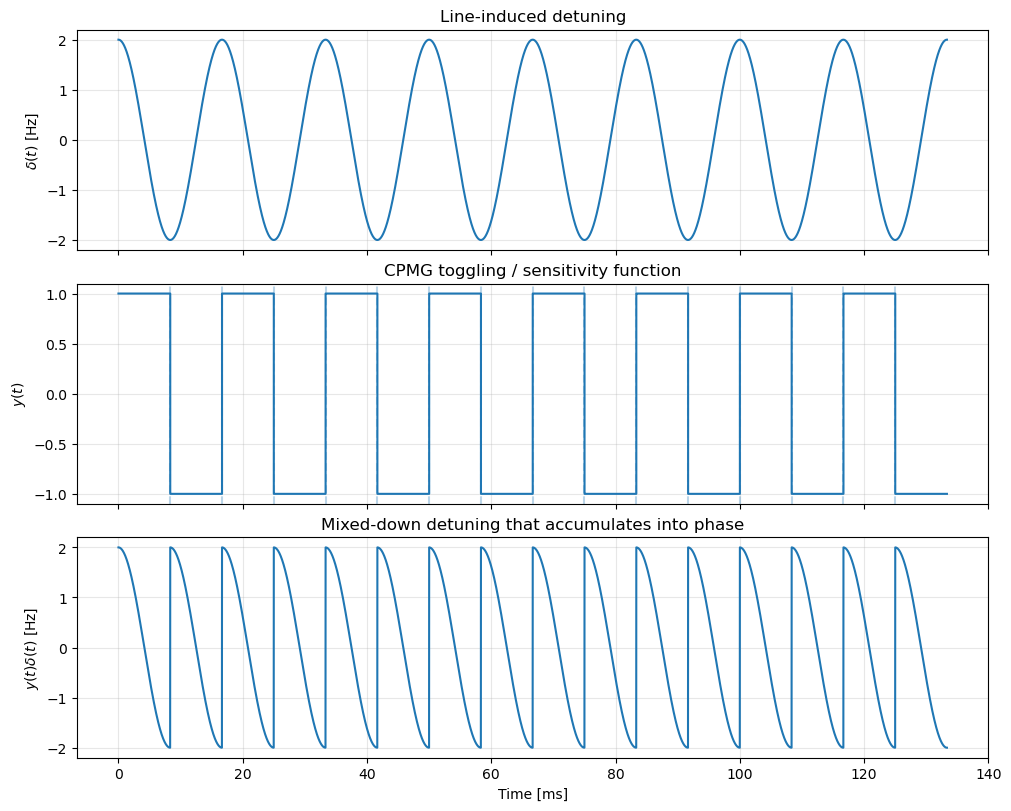

C:\Users\iamga\AppData\Local\Temp\ipykernel_40192\4241477643.py:132: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2 * np.pi * np.trapz(delta_hz, ts)


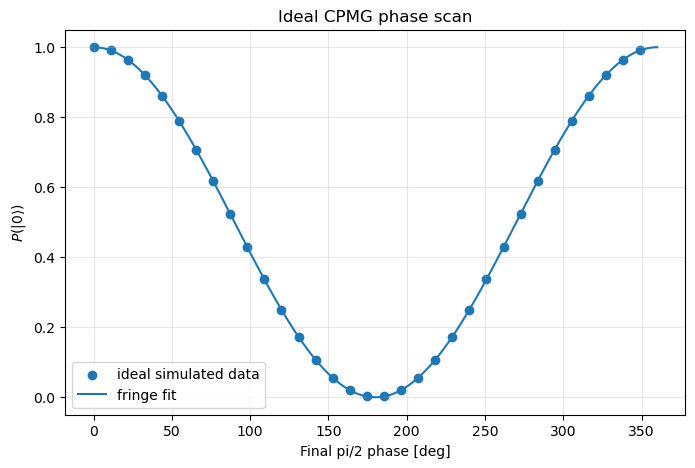

Fringe fit
----------
Offset:   0.500000
Contrast: 1.000000
Phase:    -0.000000 rad


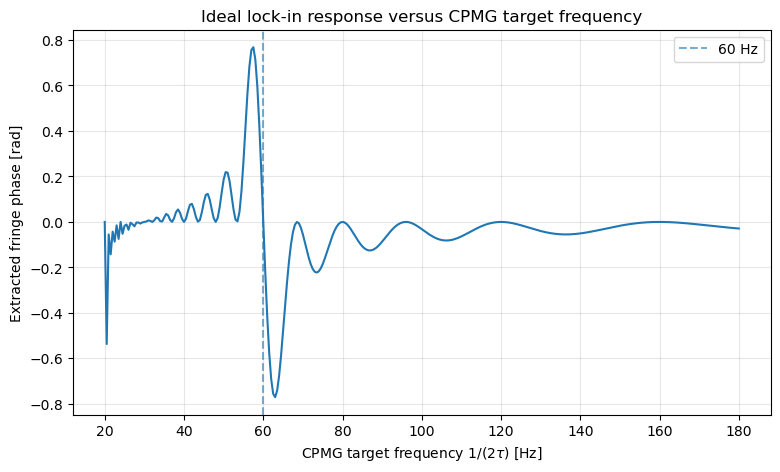

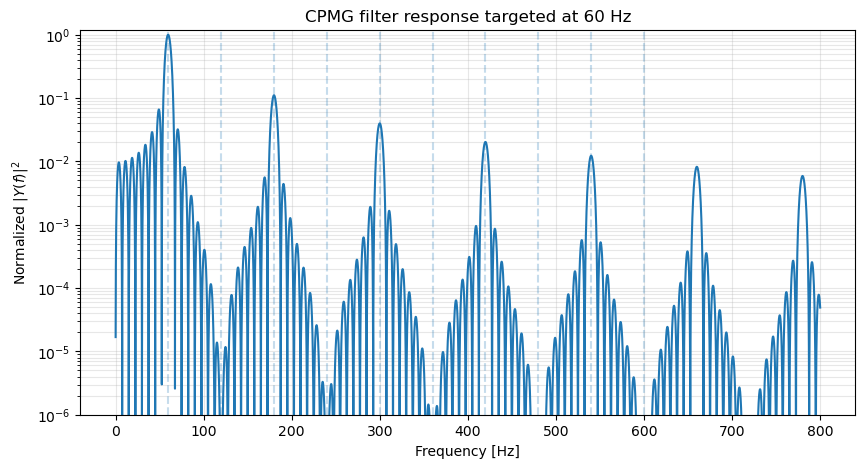

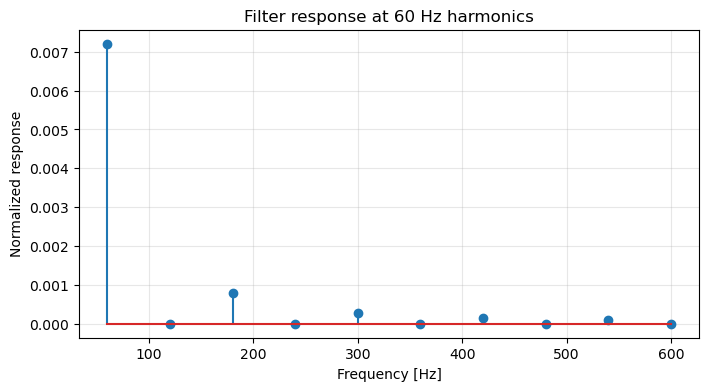

Harmonic response
-----------------
n =  1, f =   60.0 Hz, normalized response = 0.007205
n =  2, f =  120.0 Hz, normalized response = 0.000000
n =  3, f =  180.0 Hz, normalized response = 0.000801
n =  4, f =  240.0 Hz, normalized response = 0.000000
n =  5, f =  300.0 Hz, normalized response = 0.000288
n =  6, f =  360.0 Hz, normalized response = 0.000000
n =  7, f =  420.0 Hz, normalized response = 0.000147
n =  8, f =  480.0 Hz, normalized response = 0.000000
n =  9, f =  540.0 Hz, normalized response = 0.000089
n = 10, f =  600.0 Hz, normalized response = 0.000000


In [82]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Two-level system operators
# ============================================================

I2 = np.eye(2, dtype=complex)

sx = np.array([[0, 1],
               [1, 0]], dtype=complex)

sy = np.array([[0, -1j],
               [1j, 0]], dtype=complex)

sz = np.array([[1, 0],
               [0, -1]], dtype=complex)


def rotation(axis_phase, angle):
    """
    Rotation by angle around axis:
        cos(axis_phase) sigma_x + sin(axis_phase) sigma_y
    """
    sigma_phi = np.cos(axis_phase) * sx + np.sin(axis_phase) * sy
    return np.cos(angle / 2) * I2 - 1j * np.sin(angle / 2) * sigma_phi


def z_evolution(phi_rad):
    """
    Evolution under:
        H = hbar * delta(t) * sigma_z / 2

    where phi_rad = integral delta_rad_per_s(t) dt.
    """
    return np.cos(phi_rad / 2) * I2 - 1j * np.sin(phi_rad / 2) * sz


# ============================================================
# User-controlled detuning function
# ============================================================

def make_harmonic_detuning(
    base_freq_hz=60.0,
    amplitudes_hz=None,
    phases_rad=None,
    dc_hz=0.0,
):
    """
    Returns a function delta_hz(t).

    Model:
        delta(t) = dc + sum_n A_n sin(2 pi n f0 t + phi_n)

    amplitudes_hz[n-1] = amplitude of nth harmonic in Hz.
    phases_rad[n-1]    = phase of nth harmonic in radians.
    """
    amplitudes_hz = np.asarray(amplitudes_hz, dtype=float)

    if phases_rad is None:
        phases_rad = np.zeros_like(amplitudes_hz)
    else:
        phases_rad = np.asarray(phases_rad, dtype=float)

    harmonics = np.arange(1, len(amplitudes_hz) + 1)

    def delta_hz(t):
        t = np.asarray(t)
        out = dc_hz * np.ones_like(t, dtype=float)

        for n, amp, phase in zip(harmonics, amplitudes_hz, phases_rad):
            out += amp * np.sin(2 * np.pi * n * base_freq_hz * t + phase)

        return out

    return delta_hz


# ============================================================
# CPMG timing and toggling function
# ============================================================

def cpmg_timing(f_lock_hz, n_pi):
    """
    CPMG / quantum lock-in timing.

    Neighboring pi-pulse spacing:
        tau = 1 / (2 f_lock)

    Sequence:
        pi/2 - tau - pi - tau - pi - ... - tau - final pi/2
    """
    tau = 1 / (2 * f_lock_hz)
    pulse_times = tau * np.arange(1, n_pi + 1)
    total_time = (n_pi + 1) * tau

    edges = np.concatenate(([0.0], pulse_times, [total_time]))
    signs = (-1) ** np.arange(len(edges) - 1)

    return edges, pulse_times, signs, tau, total_time


def y_of_t(t, edges, signs):
    """
    Piecewise-constant sensitivity function y(t).
    """
    t = np.asarray(t)
    idx = np.searchsorted(edges[1:], t, side="right")
    idx = np.clip(idx, 0, len(signs) - 1)
    return signs[idx]


# ============================================================
# Numerical integration of arbitrary detuning
# ============================================================

def integrated_detuning_rad(
    t0,
    t1,
    delta_hz_func,
    t_start=0.0,
    samples_per_interval=300,
):
    """
    Computes:
        phi = integral_{t0}^{t1} 2 pi delta_hz(t) dt

    Output is radians.
    """
    ts = np.linspace(t0, t1, samples_per_interval)
    delta_hz = delta_hz_func(ts + t_start)
    return 2 * np.pi * np.trapz(delta_hz, ts)


# ============================================================
# CPMG experiment simulation
# ============================================================

def run_cpmg_probability(
    final_phase,
    f_lock_hz,
    n_pi,
    delta_hz_func,
    t_start=0.0,
    samples_per_interval=300,
):
    """
    Ideal deterministic CPMG experiment.

    No projection noise.
    No decoherence.
    No pulse error.
    No contrast loss.
    """
    edges, pulse_times, signs, tau, total_time = cpmg_timing(f_lock_hz, n_pi)

    # Start in |0>
    psi = np.array([1.0 + 0j, 0.0 + 0j])

    # Initial pi/2 pulse around X
    psi = rotation(0.0, np.pi / 2) @ psi

    # Free evolution plus pi pulses
    for k in range(len(edges) - 1):
        phi_z = integrated_detuning_rad(
            edges[k],
            edges[k + 1],
            delta_hz_func,
            t_start=t_start,
            samples_per_interval=samples_per_interval,
        )

        psi = z_evolution(phi_z) @ psi

        # Apply pi pulse except after final free-evolution segment
        if k < len(edges) - 2:
            psi = rotation(0.0, np.pi) @ psi

    # Final pi/2 analysis pulse
    psi = rotation(final_phase, np.pi / 2) @ psi

    # Measure population in |0>
    return float(np.abs(psi[0]) ** 2)


def fit_fringe(final_phases, populations):
    """
    Fit:
        P(phi) = offset + a cos(phi) + b sin(phi)

    Equivalent to:
        P(phi) = offset + amp cos(phi - phase)
    """
    X = np.column_stack([
        np.ones_like(final_phases),
        np.cos(final_phases),
        np.sin(final_phases),
    ])

    offset, a, b = np.linalg.lstsq(X, populations, rcond=None)[0]

    amp = np.sqrt(a**2 + b**2)
    contrast = 2 * amp
    phase = np.arctan2(b, a)

    def fit_curve(phi):
        return offset + a * np.cos(phi) + b * np.sin(phi)

    return offset, contrast, phase, fit_curve


# ============================================================
# Filter function
# ============================================================

def filter_response(freqs_hz, edges, signs):
    """
    Computes:
        Y(f) = integral y(t) exp(i 2 pi f t) dt

    We plot:
        |Y(f)|^2
    """
    freqs_hz = np.asarray(freqs_hz)
    omega = 2 * np.pi * freqs_hz

    t0 = edges[:-1]
    t1 = edges[1:]
    y = signs

    Y = np.zeros_like(freqs_hz, dtype=complex)

    nonzero = np.abs(omega) > 1e-15
    w = omega[nonzero, None]

    Y[nonzero] = np.sum(
        y[None, :]
        * (
            np.exp(1j * w * t1[None, :])
            - np.exp(1j * w * t0[None, :])
        )
        / (1j * w),
        axis=1,
    )

    # DC limit
    Y[~nonzero] = np.sum(y * (t1 - t0))

    return Y


# ============================================================
# Main parameters
# ============================================================

# CPMG sequence targeted at 60 Hz
f_lock_hz = 60.0
n_pi = 15

# Detuning model.
# This is the only place you need to change the line signal.
delta_hz_func = make_harmonic_detuning(
    base_freq_hz=60.0,
    amplitudes_hz=[
        2.0,   # 60 Hz amplitude in Hz
        0.0,   # 120 Hz
        0.0,   # 180 Hz
        0.0,   # 240 Hz
        0.0,   # 300 Hz
        0.0,   # 360 Hz
        0.0,   # 420 Hz
        0.0,   # 480 Hz
        0.0,   # 540 Hz
        0.0,   # 600 Hz
    ],
    phases_rad=[
        np.pi/2,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
    dc_hz=0.0,
)

edges, pulse_times, signs, tau, total_time = cpmg_timing(f_lock_hz, n_pi)

print(f"Target lock-in frequency: {f_lock_hz:.1f} Hz")
print(f"Pi-pulse spacing tau: {tau * 1e3:.3f} ms")
print(f"Total sequence time: {total_time * 1e3:.3f} ms")
print(f"Number of pi pulses: {n_pi}")


# ============================================================
# Plot 1: Detuning, sensitivity function, mixed signal
# ============================================================

t = np.linspace(0, total_time, 8000)
delta = delta_hz_func(t)
y = y_of_t(t, edges, signs)
mixed = y * delta

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

ax[0].plot(t * 1e3, delta)
ax[0].set_ylabel(r"$\delta(t)$ [Hz]")
ax[0].set_title("Line-induced detuning")

ax[1].step(t * 1e3, y, where="post")
for tp in pulse_times:
    ax[1].axvline(tp * 1e3, linestyle="--", alpha=0.3)
ax[1].set_ylabel(r"$y(t)$")
ax[1].set_title("CPMG toggling / sensitivity function")

ax[2].plot(t * 1e3, mixed)
ax[2].set_ylabel(r"$y(t)\delta(t)$ [Hz]")
ax[2].set_xlabel("Time [ms]")
ax[2].set_title("Mixed-down detuning that accumulates into phase")

for a in ax:
    a.grid(True, alpha=0.3)

plt.show()


# ============================================================
# Plot 2: Ideal phase scan
# ============================================================

final_phases = np.linspace(0, 2 * np.pi, 33, endpoint=False)

populations = np.array([
    run_cpmg_probability(
        final_phase=phi,
        f_lock_hz=f_lock_hz,
        n_pi=n_pi,
        delta_hz_func=delta_hz_func,
    )
    for phi in final_phases
])

offset, contrast, phase, fit_curve = fit_fringe(final_phases, populations)

phi_dense = np.linspace(0, 2 * np.pi, 500)

plt.figure(figsize=(8, 5))
plt.scatter(np.rad2deg(final_phases), populations, label="ideal simulated data")
plt.plot(np.rad2deg(phi_dense), fit_curve(phi_dense), label="fringe fit")
plt.xlabel("Final pi/2 phase [deg]")
plt.ylabel(r"$P(|0\rangle)$")
plt.title("Ideal CPMG phase scan")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Fringe fit")
print("----------")
print(f"Offset:   {offset:.6f}")
print(f"Contrast: {contrast:.6f}")
print(f"Phase:    {phase:.6f} rad")


# ============================================================
# Plot 3: Lock-in response versus CPMG target frequency
# ============================================================

scan_freqs = np.linspace(20, 180, 321)

extracted_phase = []
extracted_contrast = []

for f_scan in scan_freqs:
    pops = np.array([
        run_cpmg_probability(
            final_phase=phi,
            f_lock_hz=f_scan,
            n_pi=n_pi,
            delta_hz_func=delta_hz_func,
        )
        for phi in final_phases
    ])

    offset_i, contrast_i, phase_i, fit_i = fit_fringe(final_phases, pops)

    extracted_phase.append(phase_i)
    extracted_contrast.append(contrast_i)

extracted_phase = np.unwrap(np.array(extracted_phase))
extracted_contrast = np.array(extracted_contrast)

plt.figure(figsize=(9, 5))
plt.plot(scan_freqs, extracted_phase)
plt.axvline(60, linestyle="--", alpha=0.6, label="60 Hz")
plt.xlabel(r"CPMG target frequency $1/(2\tau)$ [Hz]")
plt.ylabel("Extracted fringe phase [rad]")
plt.title("Ideal lock-in response versus CPMG target frequency")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# Plot 4: Filter function
# ============================================================

freqs = np.linspace(0.1, 800, 25000)
Y = filter_response(freqs, edges, signs)

F = np.abs(Y) ** 2
F /= F.max()

plt.figure(figsize=(10, 5))
plt.semilogy(freqs, F)

for n in range(1, 11):
    plt.axvline(60 * n, linestyle="--", alpha=0.25)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Normalized $|Y(f)|^2$")
plt.title("CPMG filter response targeted at 60 Hz")
plt.ylim(1e-6, 1.2)
plt.grid(True, which="both", alpha=0.3)
plt.show()


# ============================================================
# Plot 5: Response at harmonics of 60 Hz
# ============================================================

harmonics = 60 * np.arange(1, 11)
Y_h = filter_response(harmonics, edges, signs)
F_h = np.abs(Y_h) ** 2
F_h /= F.max()

plt.figure(figsize=(8, 4))
plt.stem(harmonics, F_h)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized response")
plt.title("Filter response at 60 Hz harmonics")
plt.grid(True, alpha=0.3)
plt.show()

print("Harmonic response")
print("-----------------")
for n, f, val in zip(np.arange(1, 11), harmonics, F_h):
    print(f"n = {n:2d}, f = {f:6.1f} Hz, normalized response = {val:.6f}")

Using parameter file: Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt
Target lock-in frequency: 60.0 Hz
Pi-pulse spacing tau: 8.333 ms
Total sequence time: 133.333 ms
Number of pi pulses: 15


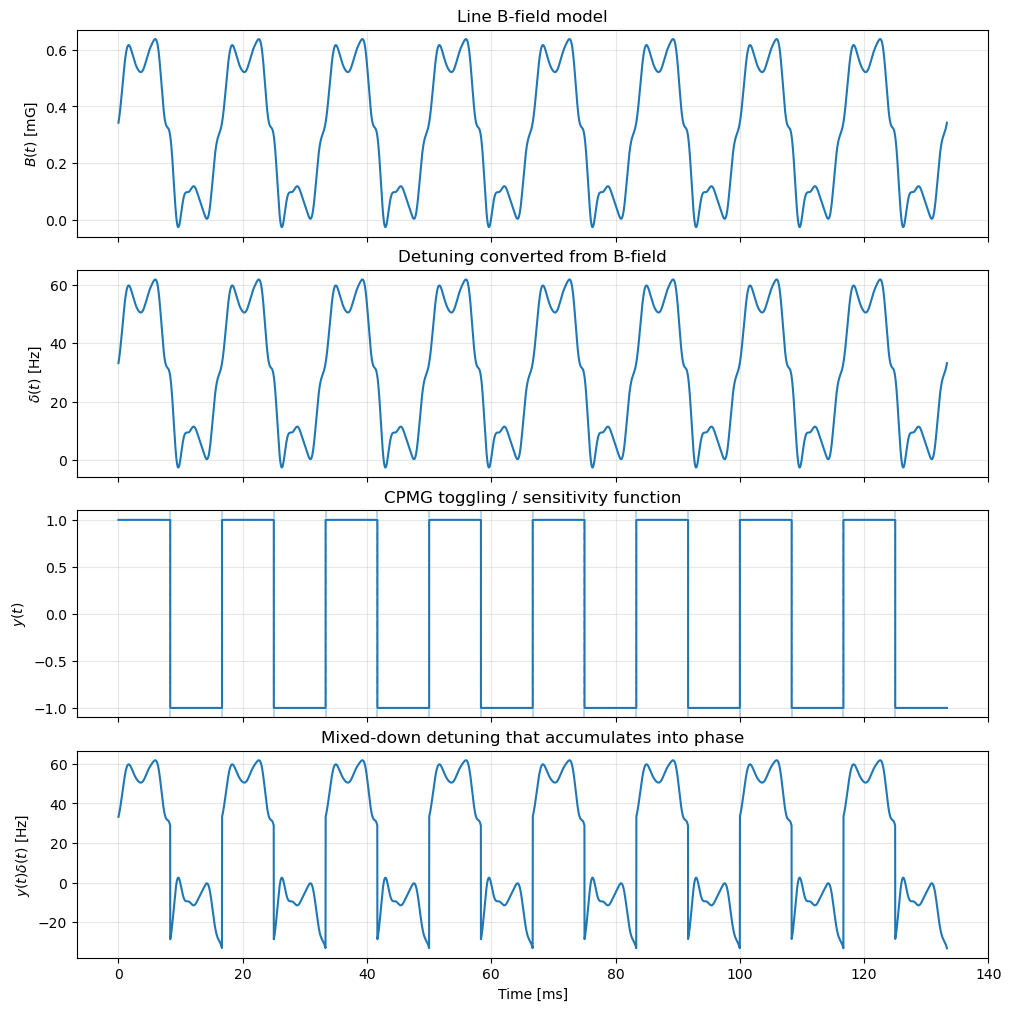

C:\Users\iamga\AppData\Local\Temp\ipykernel_40192\441390289.py:225: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2 * np.pi * np.trapz(delta_hz, ts)


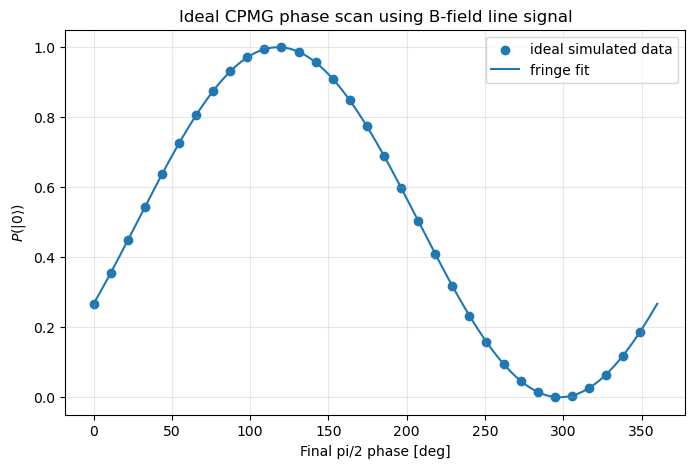

Fringe fit
----------
Offset:   0.500000
Contrast: 1.000000
Phase:    2.055754 rad


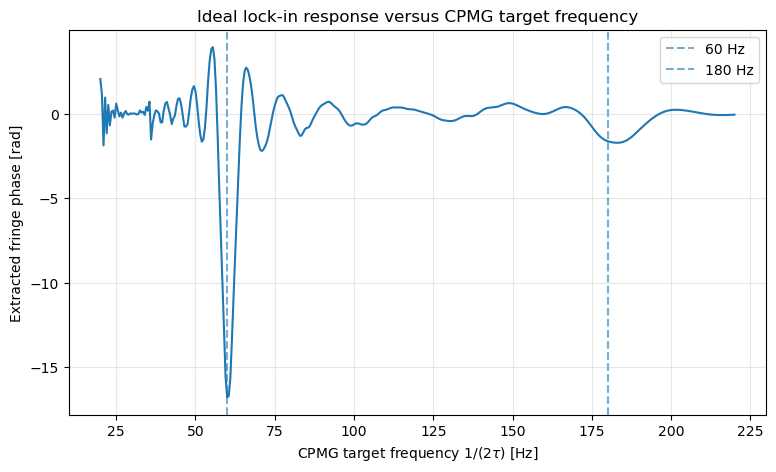

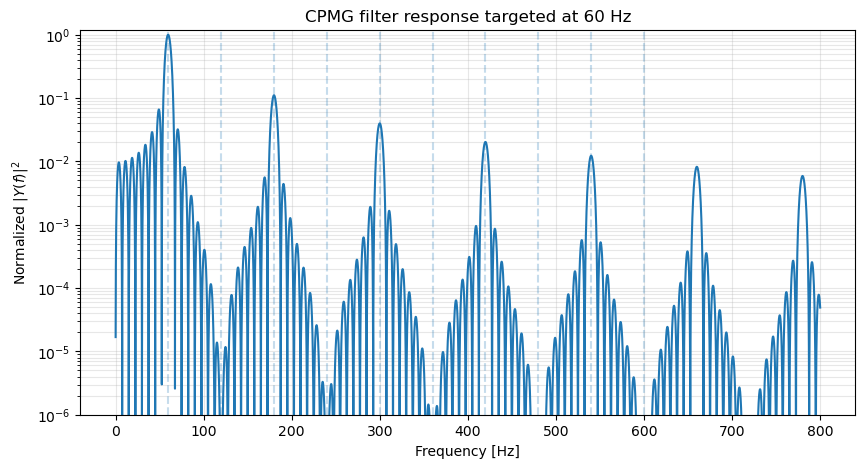

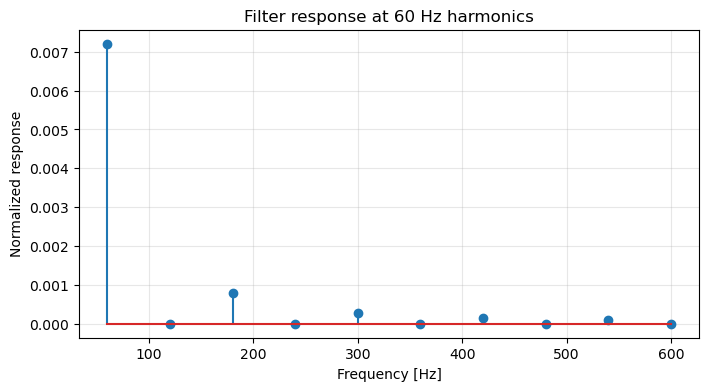

Harmonic response
-----------------
n =  1, f =   60.0 Hz, normalized response = 0.007205
n =  2, f =  120.0 Hz, normalized response = 0.000000
n =  3, f =  180.0 Hz, normalized response = 0.000801
n =  4, f =  240.0 Hz, normalized response = 0.000000
n =  5, f =  300.0 Hz, normalized response = 0.000288
n =  6, f =  360.0 Hz, normalized response = 0.000000
n =  7, f =  420.0 Hz, normalized response = 0.000147
n =  8, f =  480.0 Hz, normalized response = 0.000000
n =  9, f =  540.0 Hz, normalized response = 0.000089
n = 10, f =  600.0 Hz, normalized response = 0.000000


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import io
import os

# ============================================================
# Your B-field line-signal model
# ============================================================

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []

    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()

            if not stripped or stripped.startswith("#"):
                continue

            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)

    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))

    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]

    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]

    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals

    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)

    return B0, freqs, A_vals, phi_vals


def B_line_mG(
    t,
    B0=0.3350,
    A60=-0.3204,
    phi60=0.7425,
    A180=-0.0978,
    phi180=-0.5812,
    param_file=None,
):
    """
    Returns B-field line signal in mG.

    If param_file is given, it loads the fitted harmonics from file.
    Otherwise it uses the default 60 Hz and 180 Hz parameters.
    """
    B0_use, freqs, A_vals, phi_vals = _get_line_params(
        param_file,
        B0,
        A60,
        phi60,
        A180,
        phi180,
    )

    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)

    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)

    return y


# ============================================================
# Convert B-field to detuning
# ============================================================

LINE_TIME_SHIFT_S = 0.0025

# Your conversion:
# B_line_mG * 1e-3 converts mG -> G
# 0.097 * 1e6 is 0.097 MHz/G = 97000 Hz/G
MAGNETIC_SENSITIVITY_HZ_PER_G = 0.097 * 1e6

# Optional file loading.
# Set this to your fitted parameter file if you want to load it.
PARAM_FILE = r"Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt"

# If the file is not available, fall back to the hard-coded defaults.
if not os.path.exists(PARAM_FILE):
    PARAM_FILE = None


def delta_from_B_hz(t):
    """
    Detuning in Hz from your measured line B-field model.
    """
    return B_line_mG(
        t + LINE_TIME_SHIFT_S,
        param_file=PARAM_FILE,
    ) * 1e-3 * MAGNETIC_SENSITIVITY_HZ_PER_G


# Optional: version with DC B0 removed.
# This is often useful if you only want the AC line-induced detuning.
def delta_from_B_ac_only_hz(t):
    """
    AC-only detuning in Hz, with the mean B0 removed.
    """
    B_total_mG = B_line_mG(t + LINE_TIME_SHIFT_S, param_file=PARAM_FILE)
    B0_mG = B_line_mG(np.array([0.0]), param_file=PARAM_FILE)[0]

    return (B_total_mG - B0_mG) * 1e-3 * MAGNETIC_SENSITIVITY_HZ_PER_G


# Choose which detuning function to simulate.
# Use delta_from_B_hz to include DC + AC.
# Use delta_from_B_ac_only_hz to isolate only the line oscillation.
delta_hz_func = delta_from_B_hz
# delta_hz_func = delta_from_B_ac_only_hz


# ============================================================
# Two-level system operators
# ============================================================

I2 = np.eye(2, dtype=complex)

sx = np.array([[0, 1],
               [1, 0]], dtype=complex)

sy = np.array([[0, -1j],
               [1j, 0]], dtype=complex)

sz = np.array([[1, 0],
               [0, -1]], dtype=complex)


def rotation(axis_phase, angle):
    """
    Rotation by angle around:
        cos(axis_phase) sigma_x + sin(axis_phase) sigma_y
    """
    sigma_phi = np.cos(axis_phase) * sx + np.sin(axis_phase) * sy
    return np.cos(angle / 2) * I2 - 1j * np.sin(angle / 2) * sigma_phi


def z_evolution(phi_rad):
    """
    Evolution under:
        H = hbar * delta(t) * sigma_z / 2

    where phi_rad = integral delta_rad_per_s(t) dt.
    """
    return np.cos(phi_rad / 2) * I2 - 1j * np.sin(phi_rad / 2) * sz


# ============================================================
# CPMG timing and sensitivity function
# ============================================================

def cpmg_timing(f_lock_hz, n_pi):
    """
    CPMG / quantum lock-in timing.

    Neighboring pi-pulse spacing:
        tau = 1 / (2 f_lock)

    Sequence:
        pi/2 - tau - pi - tau - pi - ... - tau - final pi/2
    """
    tau = 1 / (2 * f_lock_hz)
    pulse_times = tau * np.arange(1, n_pi + 1)
    total_time = (n_pi + 1) * tau

    edges = np.concatenate(([0.0], pulse_times, [total_time]))
    signs = (-1) ** np.arange(len(edges) - 1)

    return edges, pulse_times, signs, tau, total_time


def y_of_t(t, edges, signs):
    """
    Piecewise-constant CPMG sensitivity function y(t).
    """
    t = np.asarray(t)
    idx = np.searchsorted(edges[1:], t, side="right")
    idx = np.clip(idx, 0, len(signs) - 1)
    return signs[idx]


# ============================================================
# Numerical integration of arbitrary detuning
# ============================================================

def integrated_detuning_rad(
    t0,
    t1,
    delta_hz_func,
    t_start=0.0,
    samples_per_interval=500,
):
    """
    Computes:
        phi = integral_{t0}^{t1} 2 pi delta_hz(t) dt

    Output is radians.
    """
    ts = np.linspace(t0, t1, samples_per_interval)
    delta_hz = delta_hz_func(ts + t_start)

    return 2 * np.pi * np.trapz(delta_hz, ts)


# ============================================================
# CPMG experiment simulation
# ============================================================

def run_cpmg_probability(
    final_phase,
    f_lock_hz,
    n_pi,
    delta_hz_func,
    t_start=0.0,
    samples_per_interval=500,
):
    """
    Ideal deterministic CPMG experiment.

    No projection noise.
    No decoherence.
    No pulse error.
    No contrast loss.
    """
    edges, pulse_times, signs, tau, total_time = cpmg_timing(f_lock_hz, n_pi)

    # Start in |0>
    psi = np.array([1.0 + 0j, 0.0 + 0j])

    # Initial pi/2 pulse around X
    psi = rotation(0.0, np.pi / 2) @ psi

    # Free evolution plus pi pulses
    for k in range(len(edges) - 1):
        phi_z = integrated_detuning_rad(
            edges[k],
            edges[k + 1],
            delta_hz_func,
            t_start=t_start,
            samples_per_interval=samples_per_interval,
        )

        psi = z_evolution(phi_z) @ psi

        # Apply pi pulse except after final free-evolution segment
        if k < len(edges) - 2:
            psi = rotation(0.0, np.pi) @ psi

    # Final pi/2 analysis pulse
    psi = rotation(final_phase, np.pi / 2) @ psi

    # Measure population in |0>
    return float(np.abs(psi[0]) ** 2)


def fit_fringe(final_phases, populations):
    """
    Fit:
        P(phi) = offset + a cos(phi) + b sin(phi)

    Equivalent to:
        P(phi) = offset + amp cos(phi - phase)
    """
    X = np.column_stack([
        np.ones_like(final_phases),
        np.cos(final_phases),
        np.sin(final_phases),
    ])

    offset, a, b = np.linalg.lstsq(X, populations, rcond=None)[0]

    amp = np.sqrt(a**2 + b**2)
    contrast = 2 * amp
    phase = np.arctan2(b, a)

    def fit_curve(phi):
        return offset + a * np.cos(phi) + b * np.sin(phi)

    return offset, contrast, phase, fit_curve


# ============================================================
# Filter function
# ============================================================

def filter_response(freqs_hz, edges, signs):
    """
    Computes:
        Y(f) = integral y(t) exp(i 2 pi f t) dt

    We plot:
        |Y(f)|^2
    """
    freqs_hz = np.asarray(freqs_hz)
    omega = 2 * np.pi * freqs_hz

    t0 = edges[:-1]
    t1 = edges[1:]
    y = signs

    Y = np.zeros_like(freqs_hz, dtype=complex)

    nonzero = np.abs(omega) > 1e-15
    w = omega[nonzero, None]

    Y[nonzero] = np.sum(
        y[None, :]
        * (
            np.exp(1j * w * t1[None, :])
            - np.exp(1j * w * t0[None, :])
        )
        / (1j * w),
        axis=1,
    )

    # DC limit
    Y[~nonzero] = np.sum(y * (t1 - t0))

    return Y


# ============================================================
# Main parameters
# ============================================================

f_lock_hz = 60.0
n_pi = 15

edges, pulse_times, signs, tau, total_time = cpmg_timing(f_lock_hz, n_pi)

print(f"Using parameter file: {PARAM_FILE}")
print(f"Target lock-in frequency: {f_lock_hz:.1f} Hz")
print(f"Pi-pulse spacing tau: {tau * 1e3:.3f} ms")
print(f"Total sequence time: {total_time * 1e3:.3f} ms")
print(f"Number of pi pulses: {n_pi}")


# ============================================================
# Plot 1: B-field, detuning, sensitivity function, mixed signal
# ============================================================

t = np.linspace(0, total_time, 10000)

B_mG = B_line_mG(t + LINE_TIME_SHIFT_S, param_file=PARAM_FILE)
delta = delta_hz_func(t)
y = y_of_t(t, edges, signs)
mixed = y * delta

fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True, constrained_layout=True)

ax[0].plot(t * 1e3, B_mG)
ax[0].set_ylabel(r"$B(t)$ [mG]")
ax[0].set_title("Line B-field model")

ax[1].plot(t * 1e3, delta)
ax[1].set_ylabel(r"$\delta(t)$ [Hz]")
ax[1].set_title("Detuning converted from B-field")

ax[2].step(t * 1e3, y, where="post")
for tp in pulse_times:
    ax[2].axvline(tp * 1e3, linestyle="--", alpha=0.3)
ax[2].set_ylabel(r"$y(t)$")
ax[2].set_title("CPMG toggling / sensitivity function")

ax[3].plot(t * 1e3, mixed)
ax[3].set_ylabel(r"$y(t)\delta(t)$ [Hz]")
ax[3].set_xlabel("Time [ms]")
ax[3].set_title("Mixed-down detuning that accumulates into phase")

for a in ax:
    a.grid(True, alpha=0.3)

plt.show()


# ============================================================
# Plot 2: Ideal phase scan
# ============================================================

final_phases = np.linspace(0, 2 * np.pi, 33, endpoint=False)

populations = np.array([
    run_cpmg_probability(
        final_phase=phi,
        f_lock_hz=f_lock_hz,
        n_pi=n_pi,
        delta_hz_func=delta_hz_func,
    )
    for phi in final_phases
])

offset, contrast, phase, fit_curve = fit_fringe(final_phases, populations)

phi_dense = np.linspace(0, 2 * np.pi, 500)

plt.figure(figsize=(8, 5))
plt.scatter(np.rad2deg(final_phases), populations, label="ideal simulated data")
plt.plot(np.rad2deg(phi_dense), fit_curve(phi_dense), label="fringe fit")
plt.xlabel("Final pi/2 phase [deg]")
plt.ylabel(r"$P(|0\rangle)$")
plt.title("Ideal CPMG phase scan using B-field line signal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Fringe fit")
print("----------")
print(f"Offset:   {offset:.6f}")
print(f"Contrast: {contrast:.6f}")
print(f"Phase:    {phase:.6f} rad")


# ============================================================
# Plot 3: Lock-in response versus CPMG target frequency
# ============================================================

scan_freqs = np.linspace(20, 220, 401)

extracted_phase = []
extracted_contrast = []

for f_scan in scan_freqs:
    pops = np.array([
        run_cpmg_probability(
            final_phase=phi,
            f_lock_hz=f_scan,
            n_pi=n_pi,
            delta_hz_func=delta_hz_func,
        )
        for phi in final_phases
    ])

    offset_i, contrast_i, phase_i, fit_i = fit_fringe(final_phases, pops)

    extracted_phase.append(phase_i)
    extracted_contrast.append(contrast_i)

extracted_phase = np.unwrap(np.array(extracted_phase))
extracted_contrast = np.array(extracted_contrast)

plt.figure(figsize=(9, 5))
plt.plot(scan_freqs, extracted_phase)
plt.axvline(60, linestyle="--", alpha=0.6, label="60 Hz")
plt.axvline(180, linestyle="--", alpha=0.6, label="180 Hz")
plt.xlabel(r"CPMG target frequency $1/(2\tau)$ [Hz]")
plt.ylabel("Extracted fringe phase [rad]")
plt.title("Ideal lock-in response versus CPMG target frequency")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# Plot 4: Filter function
# ============================================================

freqs = np.linspace(0.1, 800, 25000)
Y = filter_response(freqs, edges, signs)

F = np.abs(Y) ** 2
F /= F.max()

plt.figure(figsize=(10, 5))
plt.semilogy(freqs, F)

for n in range(1, 11):
    plt.axvline(60 * n, linestyle="--", alpha=0.25)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Normalized $|Y(f)|^2$")
plt.title("CPMG filter response targeted at 60 Hz")
plt.ylim(1e-6, 1.2)
plt.grid(True, which="both", alpha=0.3)
plt.show()


# ============================================================
# Plot 5: Response at harmonics of 60 Hz
# ============================================================

harmonics = 60 * np.arange(1, 11)
Y_h = filter_response(harmonics, edges, signs)
F_h = np.abs(Y_h) ** 2
F_h /= F.max()

plt.figure(figsize=(8, 4))
plt.stem(harmonics, F_h)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized response")
plt.title("Filter response at 60 Hz harmonics")
plt.grid(True, alpha=0.3)
plt.show()

print("Harmonic response")
print("-----------------")
for n, f, val in zip(np.arange(1, 11), harmonics, F_h):
    print(f"n = {n:2d}, f = {f:6.1f} Hz, normalized response = {val:.6f}")

C:\Users\iamga\AppData\Local\Temp\ipykernel_40192\1110573054.py:197: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2 * np.pi * np.trapz(delta_hz, ts)


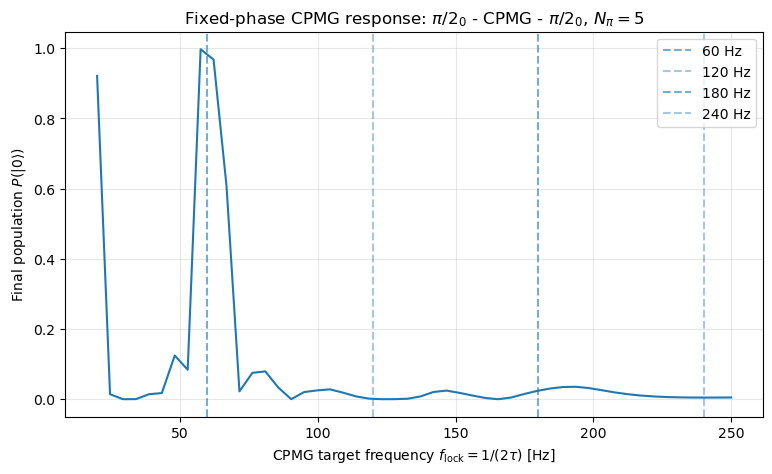

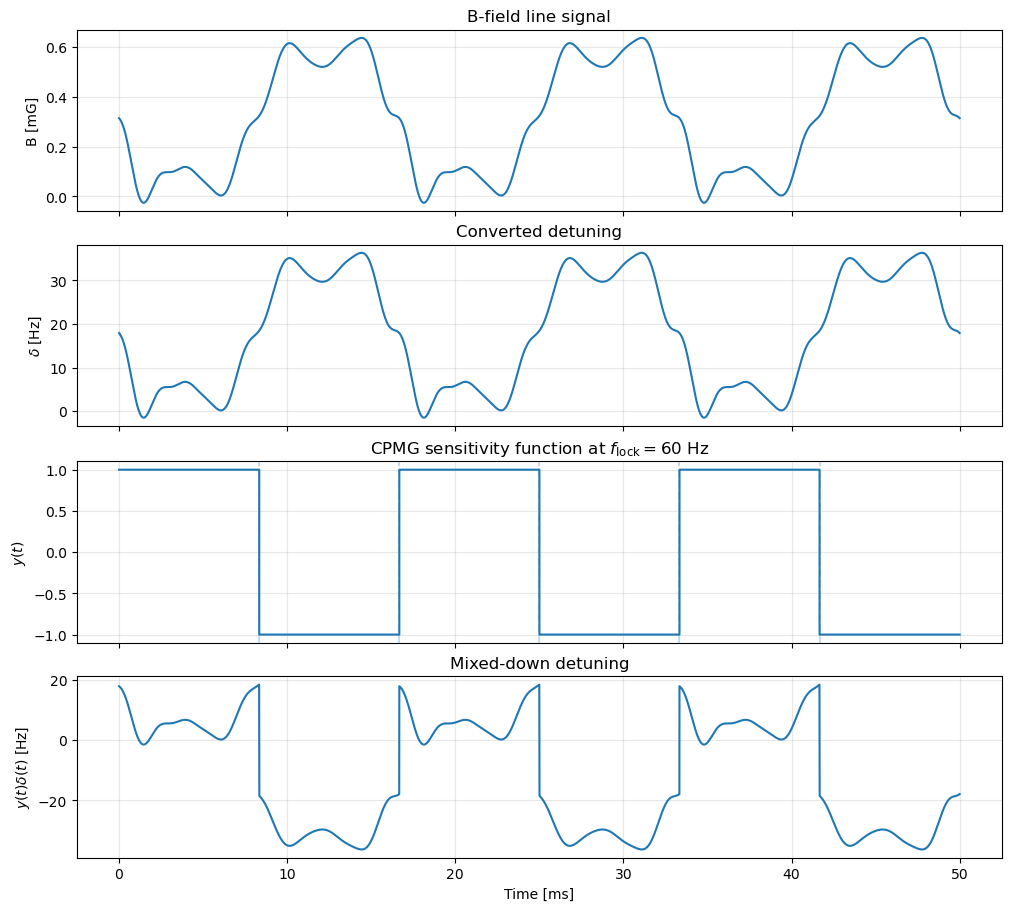

Using parameter file: Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt
N_pi = 5
For f_lock = 60.0 Hz:
  tau = 8.333333 ms
  total time = 50.000000 ms


In [108]:
import numpy as np
import matplotlib.pyplot as plt
import io
import os

# ============================================================
# Your B-field line-signal model
# ============================================================

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []

    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()

            if not stripped or stripped.startswith("#"):
                continue

            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)

    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))

    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]

    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]

    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals

    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)

    return B0, freqs, A_vals, phi_vals


def B_line_mG(
    t,
    B0=0.3350,
    A60=-0.3204,
    phi60=0.7425,
    A180=-0.0978,
    phi180=-0.5812,
    param_file=None,
):
    """
    Returns B-field line signal in mG.
    """
    B0_use, freqs, A_vals, phi_vals = _get_line_params(
        param_file,
        B0,
        A60,
        phi60,
        A180,
        phi180,
    )

    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)

    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)

    return y


# ============================================================
# Convert B-field to detuning
# ============================================================

LINE_TIME_SHIFT_S = 0.006
MAGNETIC_SENSITIVITY_HZ_PER_G = 0.057 * 1e6

PARAM_FILE = r"Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt"

if not os.path.exists(PARAM_FILE):
    PARAM_FILE = None


def delta_from_B_hz(t):
    """
    Your conversion:
        B_line_mG(t - 0.0025) * 1e-3 * 0.097 * 1e6

    Output is detuning in Hz.
    """
    return (
        B_line_mG(t - LINE_TIME_SHIFT_S, param_file=PARAM_FILE)
        * 1e-3
        * MAGNETIC_SENSITIVITY_HZ_PER_G
    )


# ============================================================
# Two-level system operators
# ============================================================

I2 = np.eye(2, dtype=complex)

sx = np.array([[0, 1],
               [1, 0]], dtype=complex)

sy = np.array([[0, -1j],
               [1j, 0]], dtype=complex)

sz = np.array([[1, 0],
               [0, -1]], dtype=complex)


def rotation(axis_phase, angle):
    """
    R_phi(theta) = exp[-i theta/2 (cos(phi) sx + sin(phi) sy)]
    """
    sigma_phi = np.cos(axis_phase) * sx + np.sin(axis_phase) * sy
    return np.cos(angle / 2) * I2 - 1j * np.sin(angle / 2) * sigma_phi


def z_evolution(phi_rad):
    """
    Evolution under H = hbar * delta(t) * sz / 2.
    """
    return np.cos(phi_rad / 2) * I2 - 1j * np.sin(phi_rad / 2) * sz


# ============================================================
# CPMG timing
# ============================================================

def cpmg_timing(f_lock_hz, n_pi):
    """
    CPMG timing with pi-pulse spacing:
        tau = 1 / (2 f_lock)

    Sequence:
        pi/2 - tau - pi - tau - pi - ... - tau - pi/2
    """
    tau = 1.0 / (2.0 * f_lock_hz)

    pulse_times = tau * np.arange(1, n_pi + 1)
    total_time = (n_pi + 1) * tau

    edges = np.concatenate(([0.0], pulse_times, [total_time]))

    return edges, pulse_times, tau, total_time


def y_of_t(t, edges):
    """
    Toggling function y(t), useful for plotting.
    """
    signs = (-1) ** np.arange(len(edges) - 1)

    t = np.asarray(t)
    idx = np.searchsorted(edges[1:], t, side="right")
    idx = np.clip(idx, 0, len(signs) - 1)

    return signs[idx]


# ============================================================
# Numerical integration
# ============================================================

def integrated_detuning_rad(
    t0,
    t1,
    delta_hz_func,
    t_start=0.0,
    samples_per_interval=500,
):
    """
    Computes:
        phi = integral 2 pi delta_hz(t) dt

    Output is radians.
    """
    ts = np.linspace(t0, t1, samples_per_interval)
    delta_hz = delta_hz_func(ts + t_start)

    return 2 * np.pi * np.trapz(delta_hz, ts)


# ============================================================
# Fixed-phase CPMG simulation
# ============================================================

def run_fixed_phase_cpmg_population(
    f_lock_hz,
    n_pi,
    delta_hz_func,
    phi_prepare=0.0,
    phi_pi=np.pi / 2,
    phi_readout=0.0,
    t_start=0.0,
    samples_per_interval=500,
):
    """
    Ideal deterministic CPMG experiment.

    Initial pi/2 phase fixed.
    Final pi/2 phase fixed.
    No projection noise.
    No decoherence.
    No pulse errors.

    Returns P(|0>).
    """
    edges, pulse_times, tau, total_time = cpmg_timing(f_lock_hz, n_pi)

    # Start in |0>
    psi = np.array([1.0 + 0j, 0.0 + 0j])

    # Initial pi/2
    psi = rotation(phi_prepare, np.pi / 2) @ psi

    # Free evolution plus pi pulses
    for k in range(len(edges) - 1):
        phi_z = integrated_detuning_rad(
            edges[k],
            edges[k + 1],
            delta_hz_func,
            t_start=t_start,
            samples_per_interval=samples_per_interval,
        )

        psi = z_evolution(phi_z) @ psi

        if k < len(edges) - 2:
            psi = rotation(phi_pi, np.pi) @ psi

    # Final pi/2
    psi = rotation(phi_readout, np.pi / 2) @ psi

    return float(np.abs(psi[0]) ** 2)


# ============================================================
# Main scan: population vs CPMG target frequency
# ============================================================

n_pi = 5

# Important: odd n_pi gives an even number of free-evolution arms,
# which cancels static detuning well in this ideal equal-spacing model.
# Here n_pi = 15 gives 16 arms.
freq_scan_hz = np.linspace(20, 250, 50)

populations = np.array([
    run_fixed_phase_cpmg_population(
        f_lock_hz=f,
        n_pi=n_pi,
        delta_hz_func=delta_from_B_hz,
        phi_prepare=0.0,
        phi_pi=np.pi / 2,
        phi_readout=0.0,
    )
    for f in freq_scan_hz
])

plt.figure(figsize=(9, 5))
plt.plot(freq_scan_hz, populations)

plt.axvline(60, linestyle="--", alpha=0.6, label="60 Hz")
plt.axvline(120, linestyle="--", alpha=0.4, label="120 Hz")
plt.axvline(180, linestyle="--", alpha=0.6, label="180 Hz")
plt.axvline(240, linestyle="--", alpha=0.4, label="240 Hz")

plt.xlabel(r"CPMG target frequency $f_{\rm lock}=1/(2\tau)$ [Hz]")
plt.ylabel(r"Final population $P(|0\rangle)$")
plt.title(
    rf"Fixed-phase CPMG response: $\pi/2_0$ - CPMG - $\pi/2_0$, "
    rf"$N_\pi={n_pi}$"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# Optional: plot the time-domain signal at one selected frequency
# ============================================================

f_example = 60.0

edges, pulse_times, tau, total_time = cpmg_timing(f_example, n_pi)

t = np.linspace(0, total_time, 8000)
B_mG = B_line_mG(t - LINE_TIME_SHIFT_S, param_file=PARAM_FILE)
delta_hz = delta_from_B_hz(t)
y = y_of_t(t, edges)
mixed = y * delta_hz

fig, ax = plt.subplots(4, 1, figsize=(10, 9), sharex=True, constrained_layout=True)

ax[0].plot(t * 1e3, B_mG)
ax[0].set_ylabel("B [mG]")
ax[0].set_title("B-field line signal")

ax[1].plot(t * 1e3, delta_hz)
ax[1].set_ylabel(r"$\delta$ [Hz]")
ax[1].set_title("Converted detuning")

ax[2].step(t * 1e3, y, where="post")
for tp in pulse_times:
    ax[2].axvline(tp * 1e3, linestyle="--", alpha=0.25)
ax[2].set_ylabel(r"$y(t)$")
ax[2].set_title(r"CPMG sensitivity function at $f_{\rm lock}=60$ Hz")

ax[3].plot(t * 1e3, mixed)
ax[3].set_ylabel(r"$y(t)\delta(t)$ [Hz]")
ax[3].set_xlabel("Time [ms]")
ax[3].set_title("Mixed-down detuning")

for a in ax:
    a.grid(True, alpha=0.3)

plt.show()

print(f"Using parameter file: {PARAM_FILE}")
print(f"N_pi = {n_pi}")
print(f"For f_lock = {f_example} Hz:")
print(f"  tau = {tau * 1e3:.6f} ms")
print(f"  total time = {total_time * 1e3:.6f} ms")

C:\Users\iamga\AppData\Local\Temp\ipykernel_40192\3041297085.py:198: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2 * np.pi * np.trapz(delta_hz, ts)


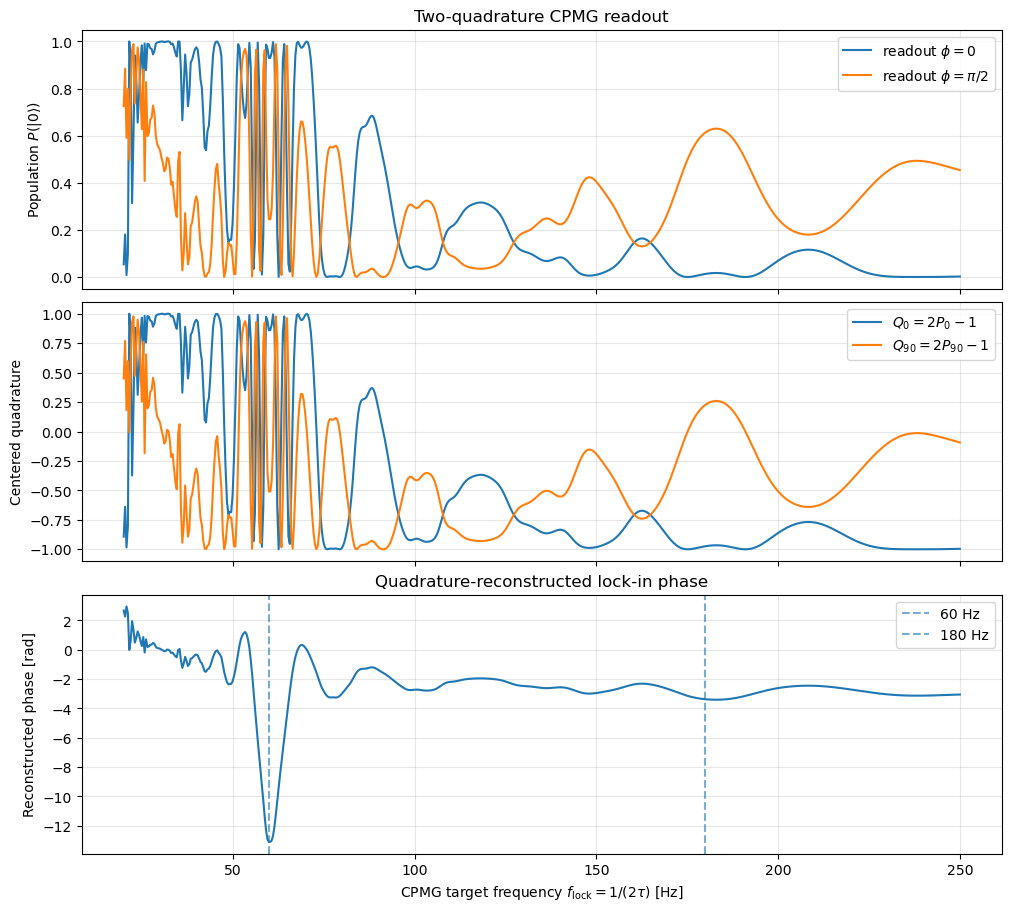

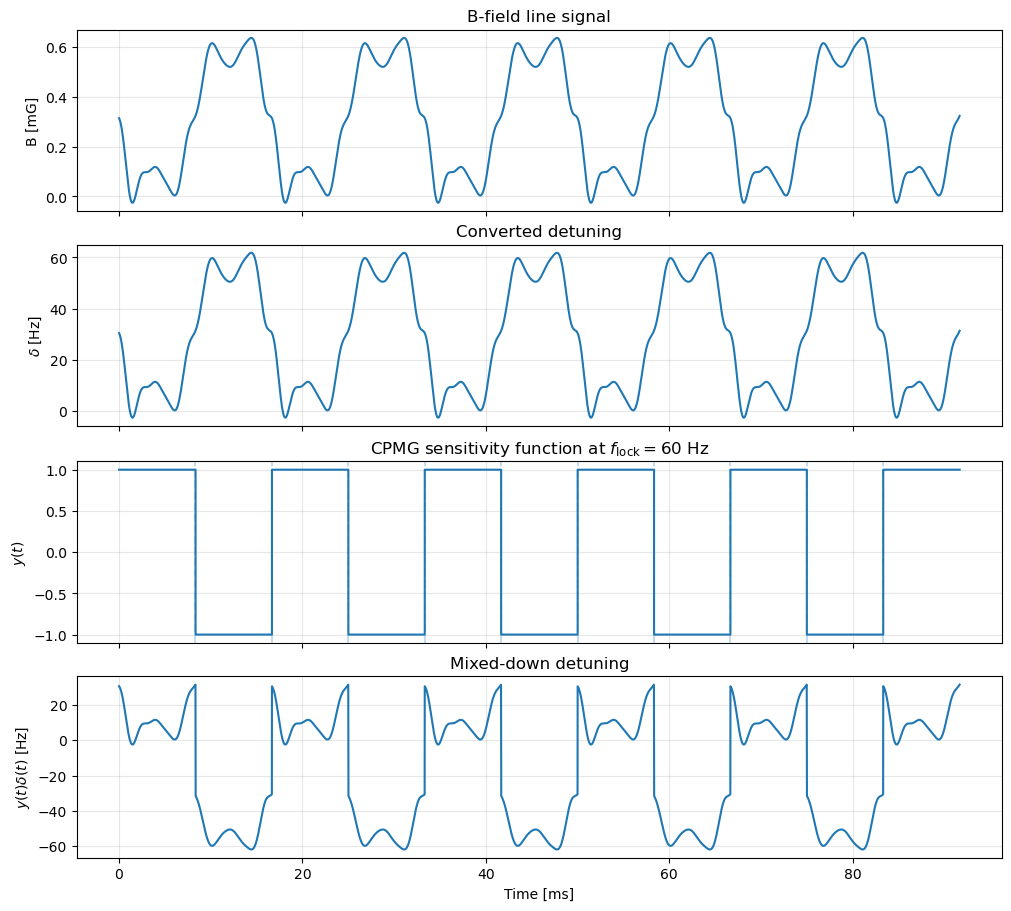

Using parameter file: Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt
DETUNING_SCALE = 1.0
N_pi = 10
For f_lock = 60.0 Hz:
  tau = 8.333333 ms
  total time = 91.666667 ms


In [102]:
import numpy as np
import matplotlib.pyplot as plt
import io
import os

# ============================================================
# Your B-field line-signal model
# ============================================================

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []

    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()

            if not stripped or stripped.startswith("#"):
                continue

            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)

    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))

    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]

    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]

    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals

    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)

    return B0, freqs, A_vals, phi_vals


def B_line_mG(
    t,
    B0=0.3350,
    A60=-0.3204,
    phi60=0.7425,
    A180=-0.0978,
    phi180=-0.5812,
    param_file=None,
):
    """
    Returns B-field line signal in mG.
    """
    B0_use, freqs, A_vals, phi_vals = _get_line_params(
        param_file,
        B0,
        A60,
        phi60,
        A180,
        phi180,
    )

    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)

    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)

    return y


# ============================================================
# Convert B-field to detuning
# ============================================================

LINE_TIME_SHIFT_S = 0.006

# Your conversion:
# B_line_mG(t - 0.0025) * 1e-3 * 0.097 * 1e6
MAGNETIC_SENSITIVITY_HZ_PER_G = 0.097 * 1e6

PARAM_FILE = r"Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt"

if not os.path.exists(PARAM_FILE):
    PARAM_FILE = None

# Optional scale factor to make plots visually obvious.
# Use 1.0 for physical values.
DETUNING_SCALE = 1.0


def delta_from_B_hz(t):
    """
    Detuning in Hz from B-line model.
    """
    return (
        DETUNING_SCALE
        * B_line_mG(t - LINE_TIME_SHIFT_S, param_file=PARAM_FILE)
        * 1e-3
        * MAGNETIC_SENSITIVITY_HZ_PER_G
    )


# ============================================================
# Two-level system operators
# ============================================================

I2 = np.eye(2, dtype=complex)

sx = np.array([[0, 1],
               [1, 0]], dtype=complex)

sy = np.array([[0, -1j],
               [1j, 0]], dtype=complex)

sz = np.array([[1, 0],
               [0, -1]], dtype=complex)


def rotation(axis_phase, angle):
    """
    R_phi(theta) = exp[-i theta/2 (cos(phi) sx + sin(phi) sy)]
    """
    sigma_phi = np.cos(axis_phase) * sx + np.sin(axis_phase) * sy
    return np.cos(angle / 2) * I2 - 1j * np.sin(angle / 2) * sigma_phi


def z_evolution(phi_rad):
    """
    Evolution under H = hbar * delta(t) * sz / 2.
    """
    return np.cos(phi_rad / 2) * I2 - 1j * np.sin(phi_rad / 2) * sz


# ============================================================
# CPMG timing
# ============================================================

def cpmg_timing(f_lock_hz, n_pi):
    """
    Pi-pulse spacing:
        tau = 1 / (2 f_lock)

    Sequence:
        pi/2 - tau - pi - tau - ... - pi - tau - pi/2
    """
    tau = 1.0 / (2.0 * f_lock_hz)
    pulse_times = tau * np.arange(1, n_pi + 1)
    total_time = (n_pi + 1) * tau
    edges = np.concatenate(([0.0], pulse_times, [total_time]))

    return edges, pulse_times, tau, total_time


def y_of_t(t, edges):
    """
    Toggling function y(t).
    """
    signs = (-1) ** np.arange(len(edges) - 1)

    t = np.asarray(t)
    idx = np.searchsorted(edges[1:], t, side="right")
    idx = np.clip(idx, 0, len(signs) - 1)

    return signs[idx]


# ============================================================
# Numerical integration
# ============================================================

def integrated_detuning_rad(
    t0,
    t1,
    delta_hz_func,
    t_start=0.0,
    samples_per_interval=500,
):
    """
    Computes phase:
        phi = integral 2 pi delta_hz(t) dt
    """
    ts = np.linspace(t0, t1, samples_per_interval)
    delta_hz = delta_hz_func(ts + t_start)

    return 2 * np.pi * np.trapz(delta_hz, ts)


# ============================================================
# CPMG simulation
# ============================================================

def run_cpmg_population(
    f_lock_hz,
    n_pi,
    delta_hz_func,
    phi_prepare=0.0,
    phi_pi=np.pi / 2,
    phi_readout=0.0,
    t_start=0.0,
    samples_per_interval=500,
):
    """
    Ideal deterministic CPMG experiment.
    """
    edges, pulse_times, tau, total_time = cpmg_timing(f_lock_hz, n_pi)

    # Start in |0>
    psi = np.array([1.0 + 0j, 0.0 + 0j])

    # Initial pi/2
    psi = rotation(phi_prepare, np.pi / 2) @ psi

    # Free evolution plus pi pulses
    for k in range(len(edges) - 1):
        phi_z = integrated_detuning_rad(
            edges[k],
            edges[k + 1],
            delta_hz_func,
            t_start=t_start,
            samples_per_interval=samples_per_interval,
        )

        psi = z_evolution(phi_z) @ psi

        if k < len(edges) - 2:
            psi = rotation(phi_pi, np.pi) @ psi

    # Final analysis pi/2
    psi = rotation(phi_readout, np.pi / 2) @ psi

    return float(np.abs(psi[0]) ** 2)


def quadrature_readout(
    f_lock_hz,
    n_pi,
    delta_hz_func,
    phi_prepare=0.0,
    phi_pi=np.pi / 2,
    t_start=0.0,
):
    """
    Runs two readout phases:
        phi_readout = 0
        phi_readout = pi/2

    Returns:
        P0, P90, Q0, Q90, phase_mod_2pi
    """
    P0 = run_cpmg_population(
        f_lock_hz=f_lock_hz,
        n_pi=n_pi,
        delta_hz_func=delta_hz_func,
        phi_prepare=phi_prepare,
        phi_pi=phi_pi,
        phi_readout=0.0,
        t_start=t_start,
    )

    P90 = run_cpmg_population(
        f_lock_hz=f_lock_hz,
        n_pi=n_pi,
        delta_hz_func=delta_hz_func,
        phi_prepare=phi_prepare,
        phi_pi=phi_pi,
        phi_readout=np.pi / 2,
        t_start=t_start,
    )

    # Convert populations to centered quadratures.
    # These are proportional to Bloch projections.
    Q0 = 2.0 * P0 - 1.0
    Q90 = 2.0 * P90 - 1.0

    # Sign convention depends on pulse phases.
    # This gives a consistent phase-like signal for this simulation convention.
    phase = np.arctan2(Q90, Q0)

    return P0, P90, Q0, Q90, phase


# ============================================================
# Main frequency scan with quadrature readout
# ============================================================

n_pi = 10

freq_scan_hz = np.linspace(20, 250, 600)

P0_list = []
P90_list = []
Q0_list = []
Q90_list = []
phase_list = []

for f in freq_scan_hz:
    P0, P90, Q0, Q90, phase = quadrature_readout(
        f_lock_hz=f,
        n_pi=n_pi,
        delta_hz_func=delta_from_B_hz,
        phi_prepare=0.0,
        phi_pi=np.pi / 2,
        t_start=0.0,
    )

    P0_list.append(P0)
    P90_list.append(P90)
    Q0_list.append(Q0)
    Q90_list.append(Q90)
    phase_list.append(phase)

P0_list = np.array(P0_list)
P90_list = np.array(P90_list)
Q0_list = np.array(Q0_list)
Q90_list = np.array(Q90_list)

phase_wrapped = np.array(phase_list)
phase_unwrapped = np.unwrap(phase_wrapped)

# Remove a smooth-ish baseline if desired.
# For now we keep the raw reconstructed phase.
phase_signal = phase_unwrapped


# ============================================================
# Plot quadrature populations
# ============================================================

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)

ax[0].plot(freq_scan_hz, P0_list, label=r"readout $\phi=0$")
ax[0].plot(freq_scan_hz, P90_list, label=r"readout $\phi=\pi/2$")
ax[0].set_ylabel(r"Population $P(|0\rangle)$")
ax[0].set_title("Two-quadrature CPMG readout")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(freq_scan_hz, Q0_list, label=r"$Q_0=2P_0-1$")
ax[1].plot(freq_scan_hz, Q90_list, label=r"$Q_{90}=2P_{90}-1$")
ax[1].set_ylabel("Centered quadrature")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(freq_scan_hz, phase_signal)
ax[2].axvline(60, linestyle="--", alpha=0.6, label="60 Hz")
ax[2].axvline(180, linestyle="--", alpha=0.6, label="180 Hz")
ax[2].set_xlabel(r"CPMG target frequency $f_{\rm lock}=1/(2\tau)$ [Hz]")
ax[2].set_ylabel("Reconstructed phase [rad]")
ax[2].set_title("Quadrature-reconstructed lock-in phase")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.show()


# ============================================================
# Optional: time-domain visualization at 60 Hz
# ============================================================

f_example = 60.0
edges, pulse_times, tau, total_time = cpmg_timing(f_example, n_pi)

t = np.linspace(0, total_time, 8000)
B_mG = B_line_mG(t - LINE_TIME_SHIFT_S, param_file=PARAM_FILE)
delta_hz = delta_from_B_hz(t)
y = y_of_t(t, edges)
mixed = y * delta_hz

fig, ax = plt.subplots(4, 1, figsize=(10, 9), sharex=True, constrained_layout=True)

ax[0].plot(t * 1e3, B_mG)
ax[0].set_ylabel("B [mG]")
ax[0].set_title("B-field line signal")

ax[1].plot(t * 1e3, delta_hz)
ax[1].set_ylabel(r"$\delta$ [Hz]")
ax[1].set_title("Converted detuning")

ax[2].step(t * 1e3, y, where="post")
for tp in pulse_times:
    ax[2].axvline(tp * 1e3, linestyle="--", alpha=0.25)
ax[2].set_ylabel(r"$y(t)$")
ax[2].set_title(r"CPMG sensitivity function at $f_{\rm lock}=60$ Hz")

ax[3].plot(t * 1e3, mixed)
ax[3].set_ylabel(r"$y(t)\delta(t)$ [Hz]")
ax[3].set_xlabel("Time [ms]")
ax[3].set_title("Mixed-down detuning")

for a in ax:
    a.grid(True, alpha=0.3)

plt.show()

print(f"Using parameter file: {PARAM_FILE}")
print(f"DETUNING_SCALE = {DETUNING_SCALE}")
print(f"N_pi = {n_pi}")
print(f"For f_lock = {f_example} Hz:")
print(f"  tau = {tau * 1e3:.6f} ms")
print(f"  total time = {total_time * 1e3:.6f} ms")